In [1]:
# focus on neural network models
# MLP, implement it, go on refining, change parameteres, and observe the changes in the results.
# work on optimizing the model
# explore MLP
# understand neural networks properly, and add more comments

In [ ]:
import pandas as pd #used to store, manipulate, clean, and analyze data
import numpy as np #used for numerical computations, working with arrays, and performing mathematical operations 

from sklearn.model_selection import train_test_split #used to split the dataset into training and testing sets
from sklearn.preprocessing import StandardScaler #used to standardize features by removing the mean and scaling to unit variance, which can improve the performance of machine learning algorithms

from sklearn.neural_network import MLPClassifier #used to create a multi-layer perceptron (MLP) classifier, which is a type of feedforward artificial neural network that can be used for classification tasks

from sklearn.metrics import (
    accuracy_score, #used to calculate the accuracy of the model, which is the ratio of correctly predicted instances to the total instances
    confusion_matrix, #used to create a confusion matrix, which shows the counts of true positives, true negatives, false positives, and false negatives
    classification_report, #used to generate a detailed report of the model's performance, including precision, recall, and F1-score for each class
    roc_auc_score, #used to calculate the area under the ROC curve, which is a measure of the model's ability to distinguish between classes
    roc_curve #used to generate the ROC curve, which plots the true positive rate against the false positive rate at various threshold settings
)

import matplotlib.pyplot as plt #used to create visualizations and plots

LOADING THE DATASET

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00254/biodeg.csv"

data = pd.read_csv( #used to read the CSV file from the specified URL and load it into a DataFrame
    url,
    sep=';',
    header=None
)

print(data.shape)

(1055, 42)


FEATURING & LABELING

In [ ]:
X = data.iloc[:, :-1] #used to select all columns except the last one
y = data.iloc[:, -1] #used to select the last column

y = y.map({'RB':1, 'NRB':0}) #used to map the labels 'RB' and 'NRB' to 1 and 0 respectively

TRAIN/TEST SPLIT

In [ ]:
X_train, X_test, y_train, y_test = train_test_split( #used to split the dataset into training and testing sets, with 20% of the data reserved for testing, and stratified sampling to maintain the class distribution
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y #
)

SCALING

In [ ]:
scaler = StandardScaler() #used to create an instance of the StandardScaler, which will be used to standardize the features by removing the mean and scaling to unit variance. 
X_train = scaler.fit_transform(X_train) #used to fit the StandardScaler to the training data and transform it
X_test = scaler.transform(X_test) #used to transform the test data using the fitted StandardScaler

MLP MODEL

In [ ]:
mlp = MLPClassifier( 
    hidden_layer_sizes=(64,32), #used to specify the architecture of the neural network, with two hidden layers containing 64 and 32 neurons respectively
    activation='relu', #used to specify the activation function for the hidden layers, which is ReLU (Rectified Linear Unit) in this case. ReLU is a popular activation function that helps the model learn complex patterns by introducing non-linearity.
    solver='adam',#used to specify the optimization algorithm for training the neural network, which is Adam in this case. 
    #Adam is an adaptive learning rate optimization algorithm that combines the advantages of both AdaGrad and RMSProp.
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42 #used to set the random seed for reproducibility
)

TRAINING & PREDICTING

In [ ]:
mlp.fit(X_train, y_train) #used to train the MLP classifier on the training data, allowing it to learn the patterns and relationships in the data to make predictions

y_pred = mlp.predict(X_test) #used to make predictions on the test data using the trained MLP classifier, which will output the predicted class labels for each instance in the test set

y_prob = mlp.predict_proba(X_test)[:,1] #used to get the predicted probabilities for the positive class (class 1) from the MLP classifier, which can be used for evaluating the model's performance

ACCURACY

In [ ]:
accuracy = accuracy_score(y_test, y_pred) #used to calculate the accuracy of the model by comparing the true labels (y_test) with the predicted labels (y_pred). The accuracy is the ratio of correctly predicted instances to the total instances in the test set.

print("Accuracy:", accuracy) 

Accuracy: 0.8578199052132701


CONFUSION MATRIX & CLASSIFICATION REPORT

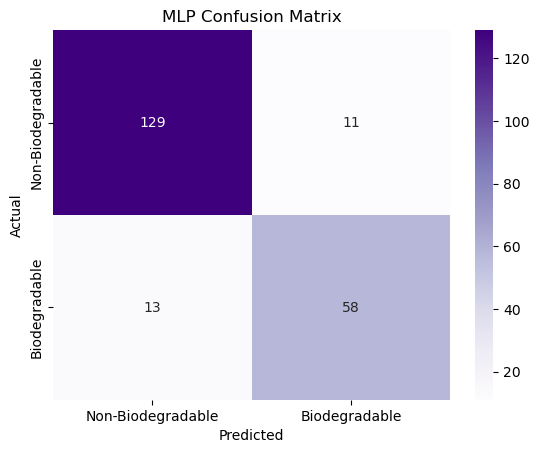


Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.92      0.91       140
           1       0.84      0.82      0.83        71

    accuracy                           0.89       211
   macro avg       0.87      0.87      0.87       211
weighted avg       0.89      0.89      0.89       211



In [29]:
cm = confusion_matrix(y_test, y_pred) #used to calculate the confusion matrix, which shows the number of correct and incorrect predictions for each class
import seaborn as sns #used to create a heatmap of the confusion matrix, which provides a visual representation of the model's performance in terms of true positives, true negatives, false positives, and false negatives
sns.heatmap(
    cm,
    annot=True, 
    fmt='d', 
    cmap='Purples', 
    xticklabels=['Non-Biodegradable','Biodegradable'],
    yticklabels=['Non-Biodegradable','Biodegradable']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MLP Confusion Matrix")
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

ROC CURVE

ROC-AUC: 0.895774647887324


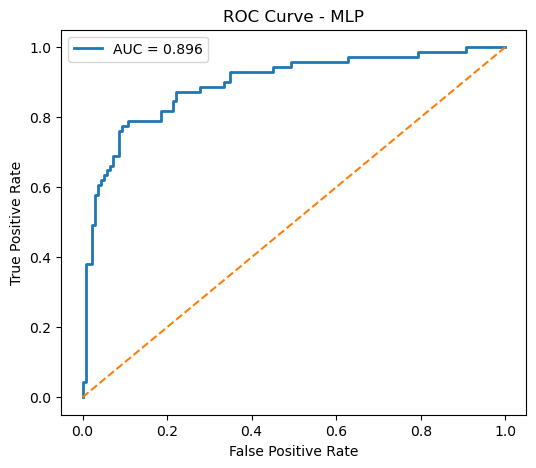

In [ ]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5)) #used to create a new figure with a specified size for the ROC curve plot

plt.plot(fpr, tpr, linewidth=2, #used to plot the ROC curve by plotting the false positive rate (fpr) against the true positive rate (tpr), with a specified line width for better visibility
         label=f"AUC = {roc_auc:.3f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - MLP")
plt.legend() 

plt.show()

In [21]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64,32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.0001,
    max_iter=1000,
    random_state=42
)
mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)

y_prob = mlp.predict_proba(X_test)[:,1]
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8862559241706162


c:\Users\Aashka Warke\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
